Colab Link:

## Import Library

In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
import torchvision
import torchvision.transforms as transforms

import numpy as np
import pandas as pd
import cv2
import os
import matplotlib.pyplot as plt

## Download German Traffic Sign Recognition Benchmark
python can download it automatically

In [11]:
import torchvision
import torchvision.transforms as transforms

transform = transforms.Compose([
    transforms.Resize((32,32)),
    transforms.ToTensor()
])

train_dataset = torchvision.datasets.GTSRB(
    root='./data',
    split='train',
    download=True,
    transform=transform
)

train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

## Porcess Data
resize image, normalize, regularization

In [12]:
transform = transforms.Compose([
    transforms.Resize((32,32)),
    transforms.RandomRotation(10),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

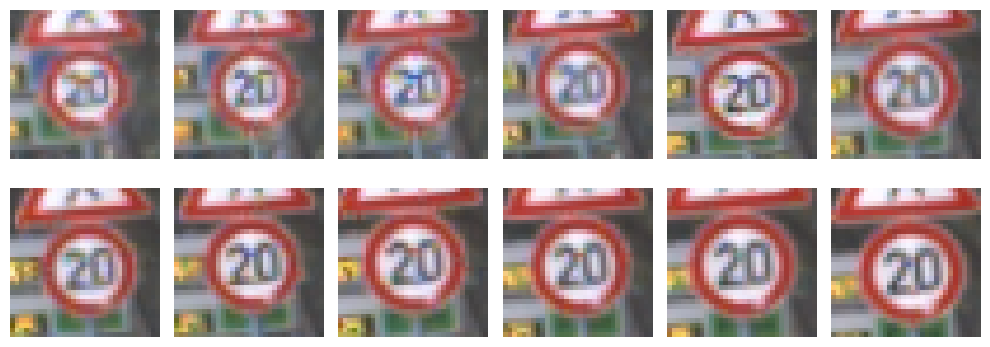

In [13]:
import matplotlib.pyplot as plt
import torchvision
import torchvision.transforms as transforms

transform = transforms.Compose([
    transforms.Resize((32,32)),
    transforms.ToTensor()
])

dataset = torchvision.datasets.GTSRB(
    root='./data',
    split='train',
    download=True,
    transform=transform
)

fig, axes = plt.subplots(2,6, figsize=(10,4))

for i, ax in enumerate(axes.flat):
    img, label = dataset[i]
    img = img.permute(1,2,0)
    ax.imshow(img)
    ax.axis("off")

plt.tight_layout()
plt.savefig("clean_samples.png")
plt.show()

## Dataset Class

In [14]:
from torch.utils.data import Dataset
class TrafficSignDataset(Dataset):
    
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform
        
    def __len__(self):
        return len(self.image_paths)
    
    def __getitem__(self, idx):
        img = cv2.imread(self.image_paths[idx])
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        
        if self.transform:
            img = self.transform(img)
            
        label = self.labels[idx]
        return img, label

In [15]:
import os

data_dir = "/Users/zhangnanzitong/Intro.-to-deep-learning/dl_env/project/data/gtsrb/GTSRB/Training"

image_paths = []
labels = []

for label in os.listdir(data_dir):
    if not label.isdigit():
        continue   # skip folders like 'gtsrb'
    folder = os.path.join(data_dir, label)
    
    if not os.path.isdir(folder):
        continue
    
    for file in os.listdir(folder):
        image_paths.append(os.path.join(folder, file))
        labels.append(int(label))

dataset = TrafficSignDataset(image_paths, labels, transform=transforms)

## Dataloder

In [16]:
from torch.utils.data import random_split

train_size = int(0.7 * len(dataset))
val_size = int(0.15 * len(dataset))
test_size = len(dataset) - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(
    dataset, [train_size, val_size, test_size]
)

train_loader = DataLoader(train_dataset,
                          batch_size=64,
                          shuffle=True)

val_loader = DataLoader(val_dataset,
                        batch_size=64)

test_loader = DataLoader(test_dataset,
                         batch_size=64)

Epoch 1
Train Loss: 2.8471
Validation Accuracy: 0.4621
------------------------------
Epoch 2
Train Loss: 1.5254
Validation Accuracy: 0.6654
------------------------------
Epoch 3
Train Loss: 1.0066
Validation Accuracy: 0.8253
------------------------------
Epoch 4
Train Loss: 0.6886
Validation Accuracy: 0.8750
------------------------------
Epoch 5
Train Loss: 0.5117
Validation Accuracy: 0.9167
------------------------------
Epoch 6
Train Loss: 0.4118
Validation Accuracy: 0.9352
------------------------------
Epoch 7
Train Loss: 0.3463
Validation Accuracy: 0.9429
------------------------------
Epoch 8
Train Loss: 0.2854
Validation Accuracy: 0.9565
------------------------------
Epoch 9
Train Loss: 0.2462
Validation Accuracy: 0.9670
------------------------------
Epoch 10
Train Loss: 0.2221
Validation Accuracy: 0.9643
------------------------------
Epoch 11
Train Loss: 0.1937
Validation Accuracy: 0.9780
------------------------------
Epoch 12
Train Loss: 0.1802
Validation Accuracy: 0.9

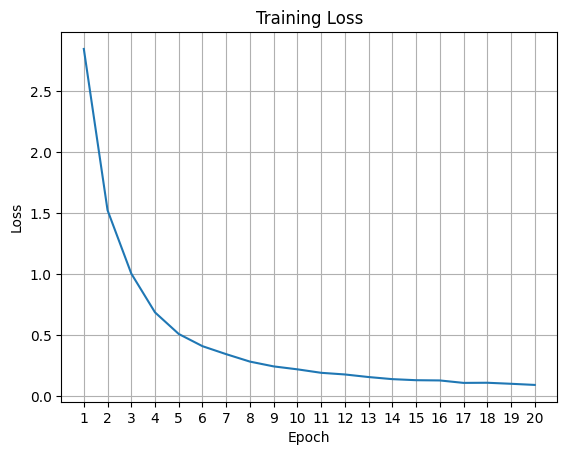

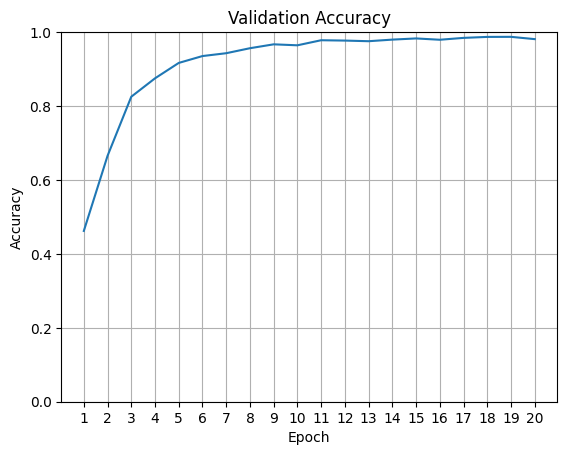

Model saved!


In [2]:
# ========================
# 1. IMPORTS
# ========================
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
import torchvision
import torchvision.transforms as transforms

# ========================
# 2. TRANSFORMS
# ========================
transform = transforms.Compose([
    transforms.Resize((32,32)),
    transforms.RandomRotation(10),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5), (0.5,0.5,0.5))
])

# ========================
# 3. LOAD DATASET
# ========================
dataset = torchvision.datasets.GTSRB(
    root='./data',
    split='train',
    download=True,
    transform=transform
)

# Split dataset
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

# DataLoaders
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64)

# ========================
# 4. MODEL
# ========================
class TrafficSignCNN(nn.Module):
    def __init__(self, num_classes=43):
        super().__init__()

        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.conv3 = nn.Conv2d(64, 128, 3, padding=1)

        self.pool = nn.MaxPool2d(2,2)

        self.fc1 = nn.Linear(128*4*4, 256)
        self.fc2 = nn.Linear(256, num_classes)

        self.dropout = nn.Dropout(0.5)

    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))
        x = self.pool(torch.relu(self.conv2(x)))
        x = self.pool(torch.relu(self.conv3(x)))

        x = x.view(x.size(0), -1)

        x = torch.relu(self.fc1(x))
        x = self.dropout(x)
        return self.fc2(x)

# ========================
# 5. SETUP
# ========================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = TrafficSignCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0008)

# ========================
# 6. TRAIN FUNCTION
# ========================
def train(model, loader):
    model.train()
    total_loss = 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)

        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)

# ========================
# 7. EVALUATE FUNCTION
# ========================
def evaluate(model, loader):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    return correct / total

train_losses = []
val_accuracies = []
# ========================
# 8. TRAIN LOOP
# ========================
epochs = 20

for epoch in range(epochs):
    train_loss = train(model, train_loader)
    val_acc = evaluate(model, val_loader)

    train_losses.append(train_loss)
    val_accuracies.append(val_acc)

    print(f"Epoch {epoch+1}")
    print(f"Train Loss: {train_loss:.4f}")
    print(f"Validation Accuracy: {val_acc:.4f}")
    print("-"*30)

import matplotlib.pyplot as plt

import matplotlib.pyplot as plt

epochs_range = range(1, len(train_losses) + 1)

# ========================
# Plot Training Loss
# ========================
plt.figure()
plt.plot(epochs_range, train_losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.xticks(epochs_range)  # force integer ticks
plt.grid()
plt.savefig("train_loss.png")
plt.show()

# ========================
# Plot Validation Accuracy
# ========================
plt.figure()
plt.plot(epochs_range, val_accuracies)
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Validation Accuracy")
plt.xticks(epochs_range)  # force integer ticks
plt.ylim(0, 1)  # accuracy range
plt.grid()
plt.savefig("val_accuracy.png")
plt.show()
# ========================
# 9. SAVE MODEL
# ========================
torch.save(model.state_dict(), "traffic_sign_model.pth")

print("Model saved!")

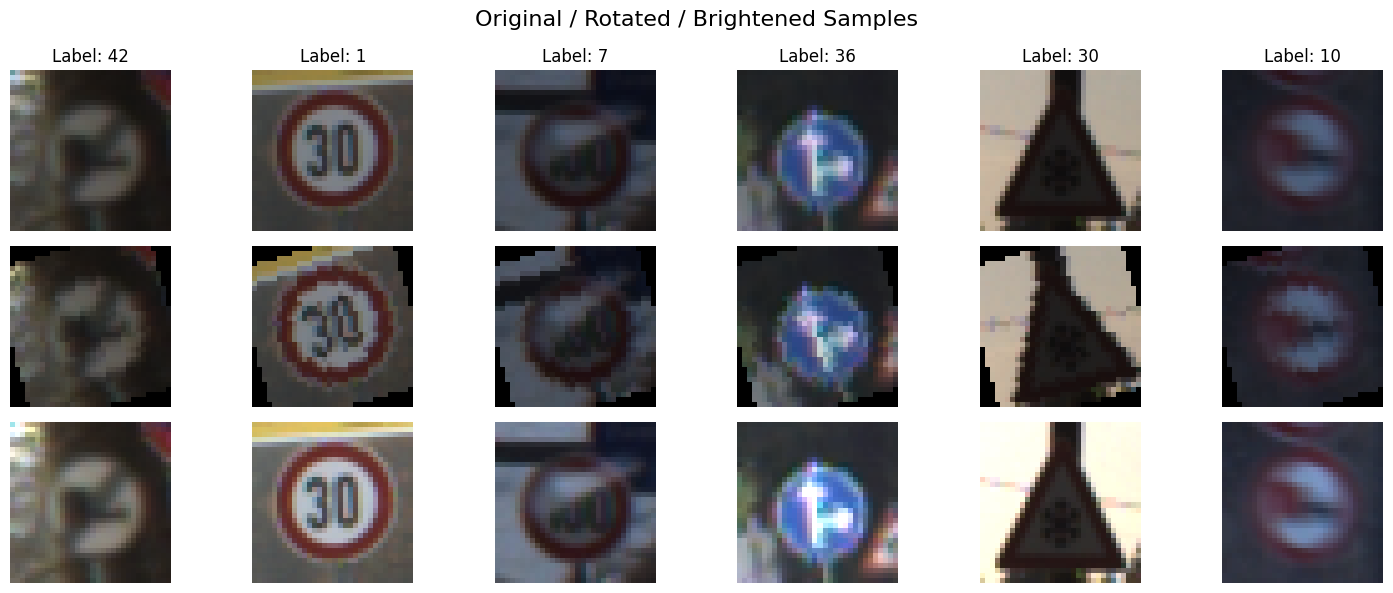

In [41]:
import matplotlib.pyplot as plt
import torchvision
import torchvision.transforms as transforms
import torchvision.transforms.functional as TF
import random
import torch

# ========================
# Transforms
# ========================
transform = transforms.Compose([
    transforms.Resize((32,32)),
    transforms.ToTensor()
])

dataset = torchvision.datasets.GTSRB(
    root='./data',
    split='train',
    download=True,
    transform=transform
)

# ========================
# Pick some random images
# ========================
num_samples = 6  # number per row
indices = random.sample(range(len(dataset)), num_samples)

# ========================
# Prepare figure
# ========================
fig, axes = plt.subplots(3, num_samples, figsize=(15,6))
fig.suptitle("Original / Rotated / Brightened Samples", fontsize=16)

for col, idx in enumerate(indices):
    img, label = dataset[idx]
    
    # Original
    orig_img = img.permute(1,2,0).numpy()
    axes[0, col].imshow(orig_img)
    axes[0, col].set_title(f"Label: {label}")
    axes[0, col].axis("off")
    
    # Rotated
    rotated = TF.rotate(TF.to_pil_image(img), 15)
    rotated = transform(rotated).permute(1,2,0).numpy()
    axes[1, col].imshow(rotated)
    axes[1, col].axis("off")
    
    # Brightened
    bright = TF.adjust_brightness(TF.to_pil_image(img), 1.5)
    bright = transform(bright).permute(1,2,0).numpy()
    axes[2, col].imshow(bright)
    axes[2, col].axis("off")

# ========================
# Show and save
# ========================
plt.tight_layout()
plt.subplots_adjust(top=0.88)
plt.savefig("traffic_sign_samples.png")
plt.show()

In [1]:
import os
import cv2
import torch
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision
from torchvision.models.detection import fasterrcnn_resnet50_fpn
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# ---------------------------
# Dataset Class for GTSDB
# ---------------------------
class GTSDBDataset(Dataset):
    def __init__(self, img_dir, annotations_file, transform=None, resize=(256, 256)):
        self.img_dir = img_dir
        self.transform = transform
        self.resize = resize
        
        # Read annotations from gt.txt
        self.annotations = []
        with open(annotations_file) as f:
            for line in f:
                parts = line.strip().split(';')
                filename = parts[0]
                x1, y1, x2, y2 = map(int, parts[1:5])
                label = int(parts[5])
                self.annotations.append({
                    "filename": filename,
                    "boxes": [[x1, y1, x2, y2]],
                    "labels": [label]
                })

    def __len__(self):
        return len(self.annotations)

    def __getitem__(self, idx):
        ann = self.annotations[idx]
        img_path = os.path.join(self.img_dir, ann["filename"])
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        orig_h, orig_w = img.shape[:2]

        # Resize image
        img = cv2.resize(img, self.resize)
        new_h, new_w = self.resize

        # Scale bounding boxes
        scale_x = new_w / orig_w
        scale_y = new_h / orig_h
        boxes = [[b[0]*scale_x, b[1]*scale_y, b[2]*scale_x, b[3]*scale_y] for b in ann["boxes"]]

        # Convert to tensors
        boxes = torch.tensor(boxes, dtype=torch.float32)
        labels = torch.tensor(ann["labels"], dtype=torch.int64)
        target = {"boxes": boxes, "labels": labels}

        # Transform image
        if self.transform:
            img = self.transform(img)
        else:
            img = torch.from_numpy(img).permute(2,0,1).float() / 255.0

        return img, target

# ---------------------------
# Paths and Dataset
# ---------------------------
img_dir = "/Users/zhangnanzitong/Intro.-to-deep-learning/dl_env/project/TrainIJCNN2013"
annotations_file = os.path.join(img_dir, "gt.txt")

dataset = GTSDBDataset(img_dir, annotations_file, resize=(256, 256))

# Split into train/val (80/20)
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True, collate_fn=lambda x: tuple(zip(*x)))
val_loader = DataLoader(val_dataset, batch_size=4, shuffle=False, collate_fn=lambda x: tuple(zip(*x)))

# ---------------------------
# Model Setup
# ---------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load pretrained Faster R-CNN
model = fasterrcnn_resnet50_fpn(weights=torchvision.models.detection.FasterRCNN_ResNet50_FPN_Weights.DEFAULT)

# Replace classifier for 43 traffic signs + background
num_classes = 44
in_features = model.roi_heads.box_predictor.cls_score.in_features
model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)
model.to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=5e-4)

# ---------------------------
# Training Loop
# ---------------------------
num_epochs = 5
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0

    for images, targets in train_loader:
        images = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k,v in t.items()} for t in targets]

        loss_dict = model(images, targets)
        losses = sum(loss for loss in loss_dict.values())

        optimizer.zero_grad()
        losses.backward()
        optimizer.step()

        running_loss += losses.item()

    avg_loss = running_loss / len(train_loader)

    # ---------------------------
    # Validation accuracy (simplified: IoU > 0.5 for top prediction)
    # ---------------------------
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, targets in val_loader:
            images = [img.to(device) for img in images]
            targets = [{k: v.to(device) for k,v in t.items()} for t in targets]

            preds = model(images)
            for pred, target in zip(preds, targets):
                if len(pred['boxes']) == 0:
                    continue
                # check if top score prediction matches label
                top_idx = pred['scores'].argmax()
                pred_label = pred['labels'][top_idx].item()
                true_label = target['labels'][0].item()
                if pred_label == true_label:
                    correct += 1
                total += 1

    val_acc = correct / total if total > 0 else 0.0

    print(f"Epoch {epoch+1}/{num_epochs} - Train Loss: {avg_loss:.4f} - Val Acc: {val_acc*100:.2f}%")

Epoch 1/5 - Train Loss: 0.2392 - Val Acc: 7.59%
Epoch 2/5 - Train Loss: 0.1870 - Val Acc: 10.57%
Epoch 3/5 - Train Loss: 0.1788 - Val Acc: 18.93%
Epoch 4/5 - Train Loss: 0.1645 - Val Acc: 22.62%
Epoch 5/5 - Train Loss: 0.1474 - Val Acc: 18.13%
